In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import random


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

In [4]:
!pip install statsmodels

In [5]:
import statsmodels

In [6]:
pip install -U kaleido

Note: you may need to restart the kernel to use updated packages.


In [7]:
import plotly.express as px
import plotly.io as pio

<h1 style="font-size: 3em; font-weight: bold; color: #2E86AB; text-align: center;">
    Временные ряды
</h1>

# №1

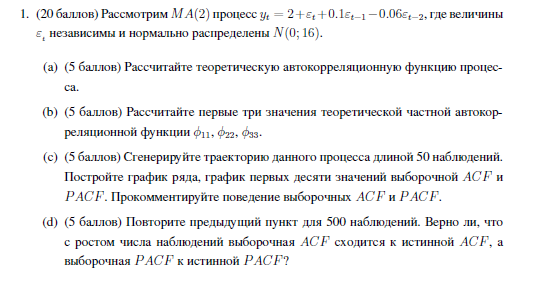

## c)

In [12]:
from statsmodels.tsa.arima_process import ArmaProcess

In [13]:
ar = np.array([1])       # Генерируем процесс ARMA, но нам нужен MA, поэтому AR часть не используем
ma = np.array([1, 1, 0.1, -0.06])
sigma = 4

MA_2 = ArmaProcess(ar, ma)
MA_2 = MA_2.generate_sample(nsample=50, scale=sigma)
MA_2 = MA_2 + 2 #добавляю константу, так как шенерировал без нее

In [14]:
import matplotlib.pyplot as plt

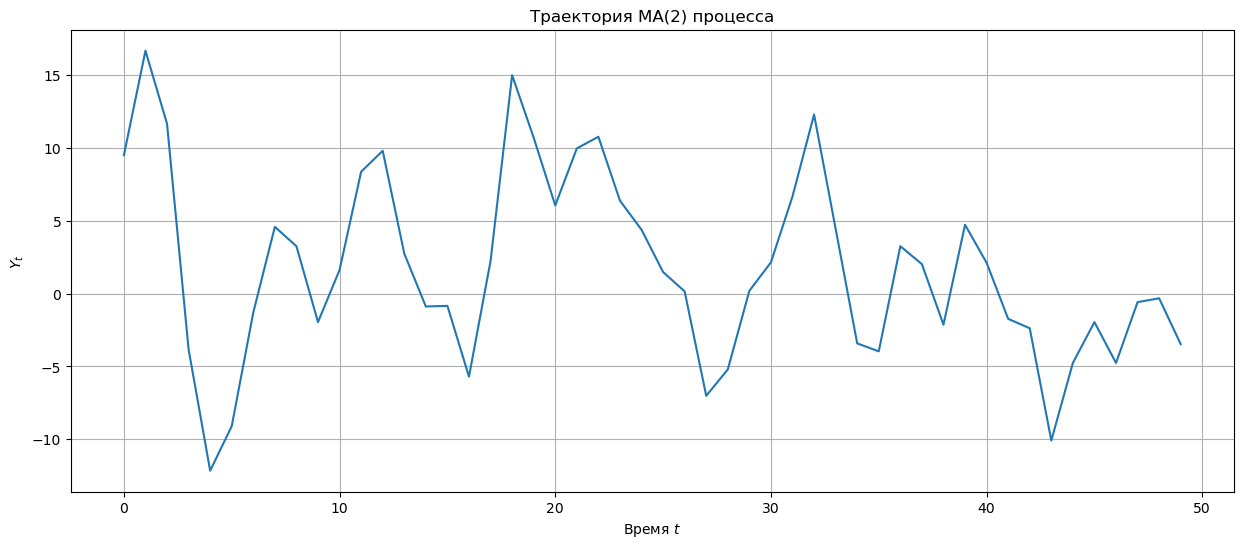

In [15]:
plt.figure(figsize=(15, 6))
plt.plot(MA_2)
plt.title("Траектория MA(2) процесса")
plt.xlabel("Время $t$")
plt.ylabel("$Y_t$")
plt.grid(True)
plt.show()

### ACF и PACF

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

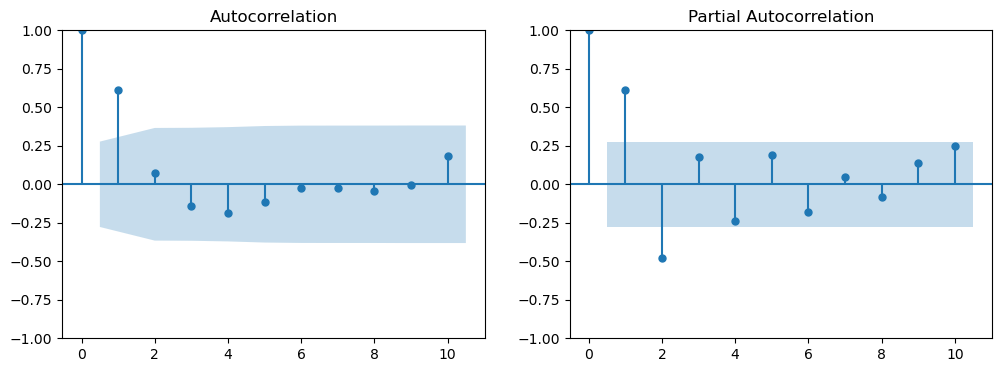

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(MA_2, lags=10, ax=ax[0])
plot_pacf(MA_2, lags=10, ax=ax[1])
plt.show()

## d)

In [20]:
MA_2_500 = ArmaProcess(ar, ma)
MA_2_500 = MA_2_500.generate_sample(nsample=500, scale=sigma)
MA_2_500 = MA_2_500 + 2 #добавляю константу, так как генерировал без нее

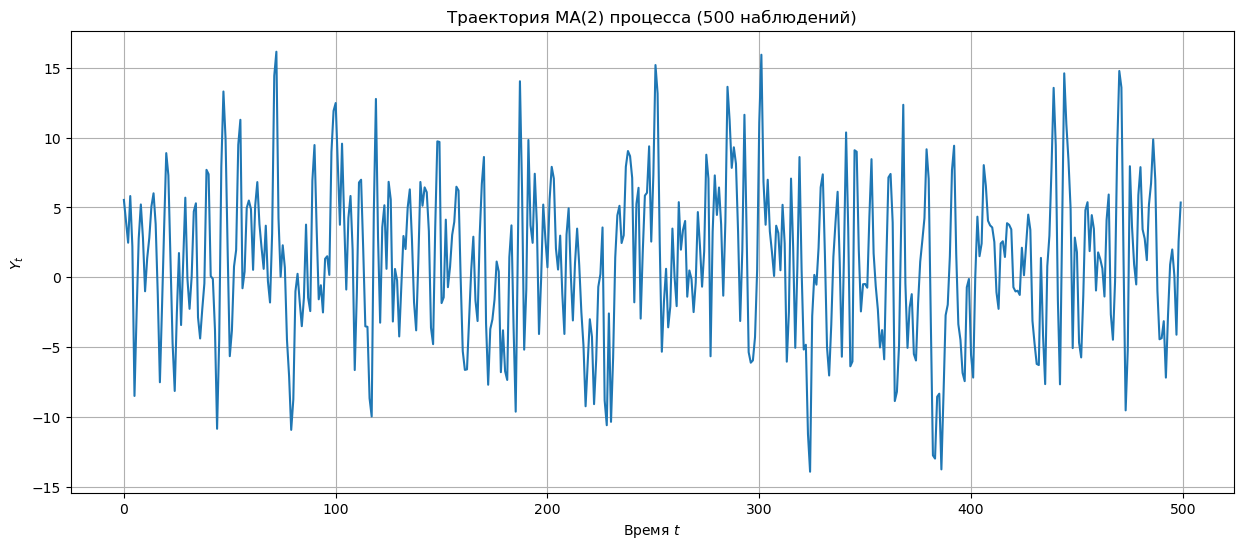

In [21]:
plt.figure(figsize=(15, 6))
plt.plot(MA_2_500)
plt.title("Траектория MA(2) процесса (500 наблюдений)")
plt.xlabel("Время $t$")
plt.ylabel("$Y_t$")
plt.grid(True)
plt.show()

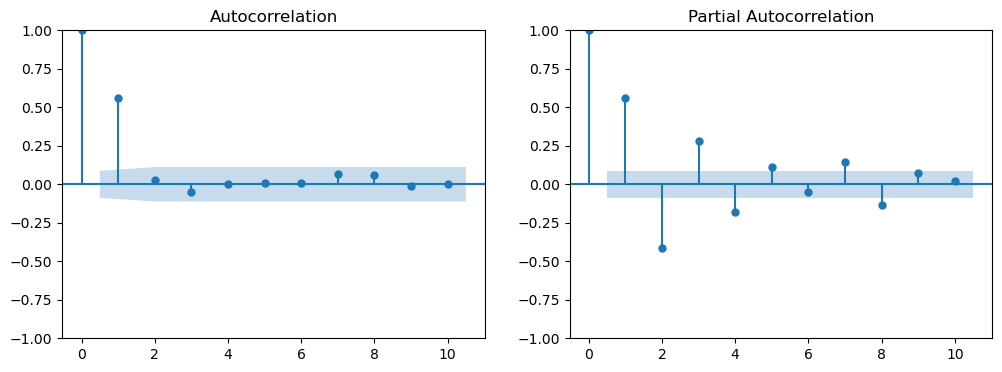

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(MA_2_500, lags=10, ax=ax[0])
plot_pacf(MA_2_500, lags=10, ax=ax[1])
plt.show()

Для 50 наблюдений оценка ACF неустойчива из-за малой выборки => **видим на графике снижение ACF с ростом лага**. Для 500 наблюдений оценка стабилизируется. По теории ACF должна обрываться после лага 2, но в исходном процессе коэффициент перед ε_{t-2} очень маленький (-0.06), поэтому на графике мы **не видим четкого обрыва после 2 лага (видим после первого)**.\
На графике для 500 наблюдений четко видно, что **PACF постепенно затухает, что соответствует свойству PACF для MA процессов.** Из-за высокой точности оценок PACF выходит за ДИ до 8 лага. Для 50 наблюдений оценка PACF менее точна, из-за этого **все значения начиная со 2 лага внутри широкого ДИ**

# №2 

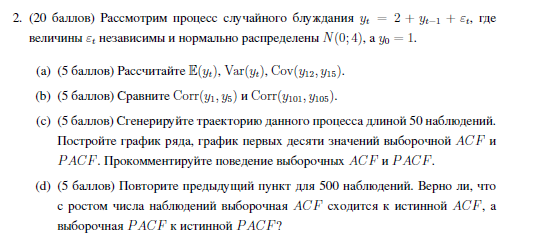

In [26]:
eps = np.random.normal(0, 2, 50)

y0 = 1
n=50
y = np.zeros(n)
y[0] = y0

# Генерация процесса
for t in range(1, n):
    y[t] = 2 + y[t-1] + eps[t]


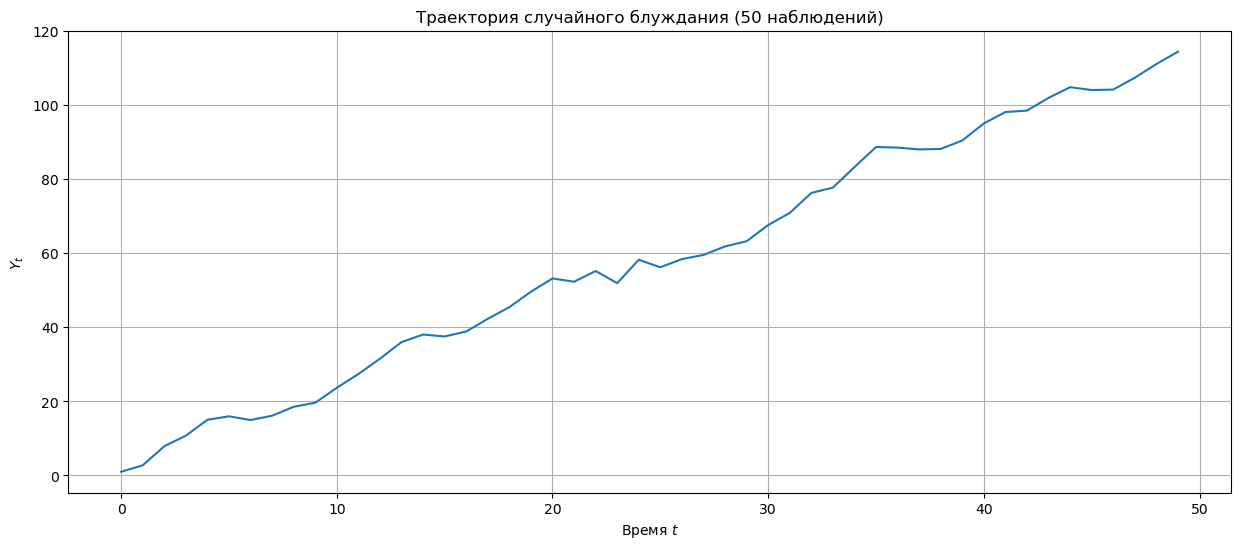

In [27]:
plt.figure(figsize=(15, 6))
plt.plot(y)
plt.title("Траектория случайного блуждания (50 наблюдений)")
plt.xlabel("Время $t$")
plt.ylabel("$Y_t$")
plt.grid(True)
plt.show()

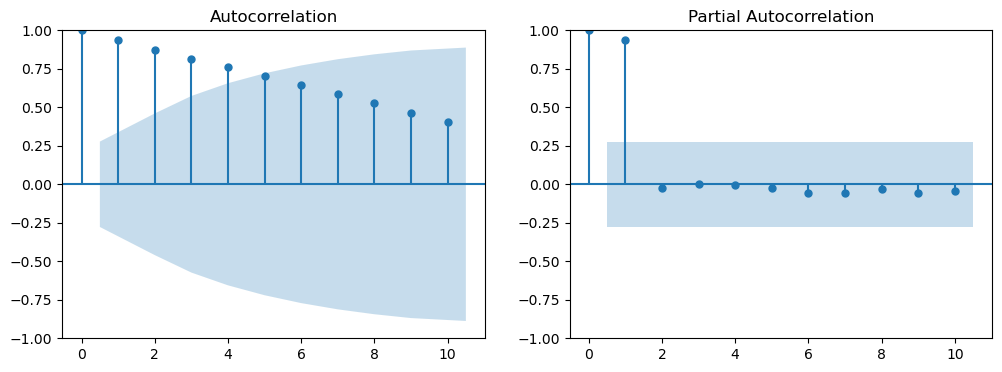

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y, lags=10, ax=ax[0])
plot_pacf(y, lags=10, ax=ax[1])
plt.show()

## Для 500 наблюдений

In [30]:
eps = np.random.normal(0, 2, 500)

y0 = 1
n=500
y = np.zeros(n)
y[0] = y0

# Генерация процесса
for t in range(1, n):
    y[t] = 2 + y[t-1] + eps[t]


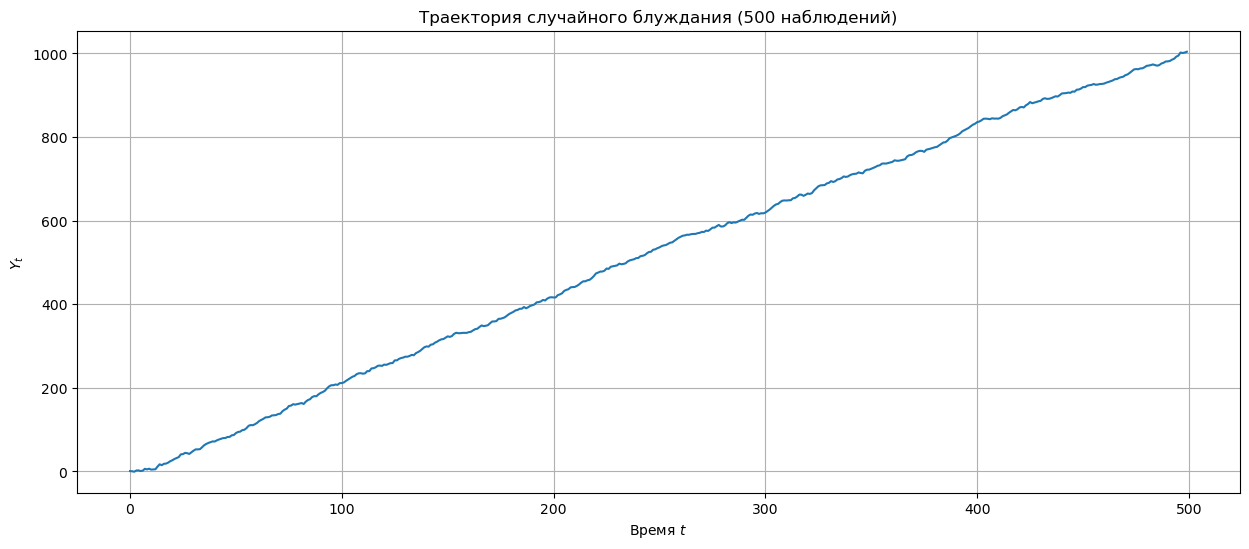

In [31]:
plt.figure(figsize=(15, 6))
plt.plot(y)
plt.title("Траектория случайного блуждания (500 наблюдений)")
plt.xlabel("Время $t$")
plt.ylabel("$Y_t$")
plt.grid(True)
plt.show()

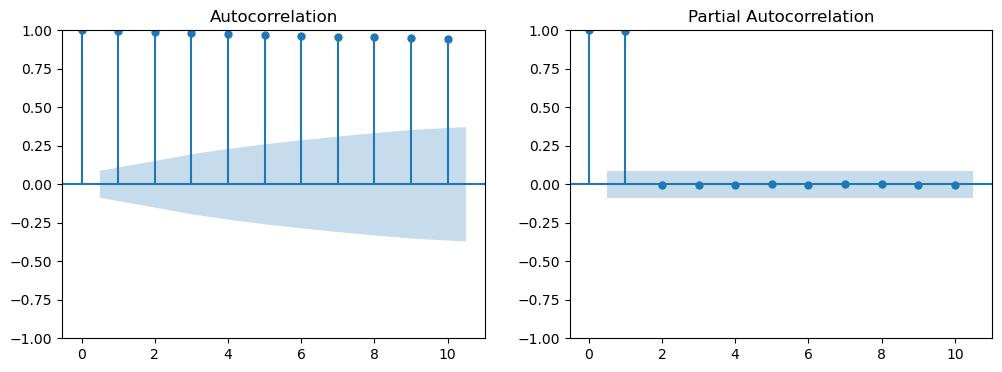

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y, lags=10, ax=ax[0])
plot_pacf(y, lags=10, ax=ax[1])
plt.show()

**Данный процесс не стационарный, поэтому ACF не обрывается**. Новое значение включает все предыдущие шоки, поэтому корреляция остается большой при росте лагов. На 50 наблюдениях она все же достаточно сильно снижается, и на 10 лаге равна уже примерно 0.4. **При 500 наблюдениях ACF стремится к теоретической ACF, поэтому корреляция на 10 лаге почти не снизилась относительно первого лага (>0.9).**\
Процесс зависит только от своего значения в предыдущий момент, поэтому PACF резко обрывается на 1 лаге. На 2 лаге и далее PACF близка к 0. **Сходимость к теоретическим значениям не проверить**, так как для нестационарных рядов эти истинные значения не определены

# №3

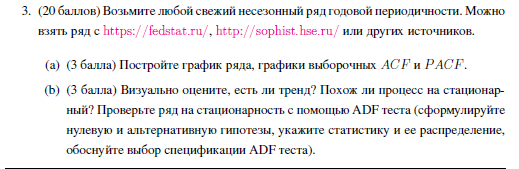

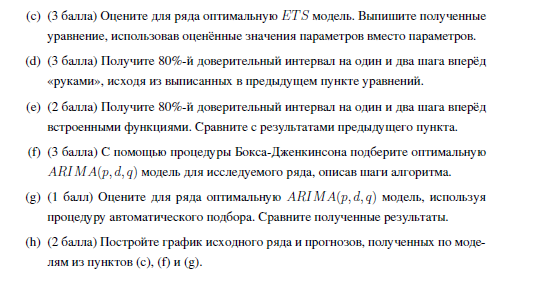

**Я выбрал ряд, отображающий динамику ИПЦ в Японии**

In [38]:
japan = pd.read_csv('df00.csv')

In [39]:
japan.head()

,observation_date,DDOE01JPA086NWDB
0,1960-01-01,19.1861
1,1961-01-01,20.9130
2,1962-01-01,21.9378
3,1963-01-01,23.1055
4,1964-01-01,24.1902


In [40]:
japan['id'] = 1

In [41]:
japan['observation_date'] = pd.to_datetime(japan['observation_date'])

In [42]:
japan = japan.rename(columns={'DDOE01JPA086NWDB': 'value'})


In [43]:
import plotly.graph_objects as go

## a)

In [45]:
fig = go.Figure()
seed_everything()
random_ids = np.random.choice(japan["id"].unique(), 1, replace=False)   

for i in random_ids:
    fig.add_trace(
        go.Scatter(x=japan[japan["id"] == i]["observation_date"], y=japan[japan["id"] == i]["value"], name=str(i))
    )
fig.update_layout(title="Data on Consumer Price Index for Japan", xaxis_title="Date", yaxis_title="Value")
fig.show()

C:\Users\User\anaconda3\Lib\site-packages\kaleido\__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




### ACF PACF

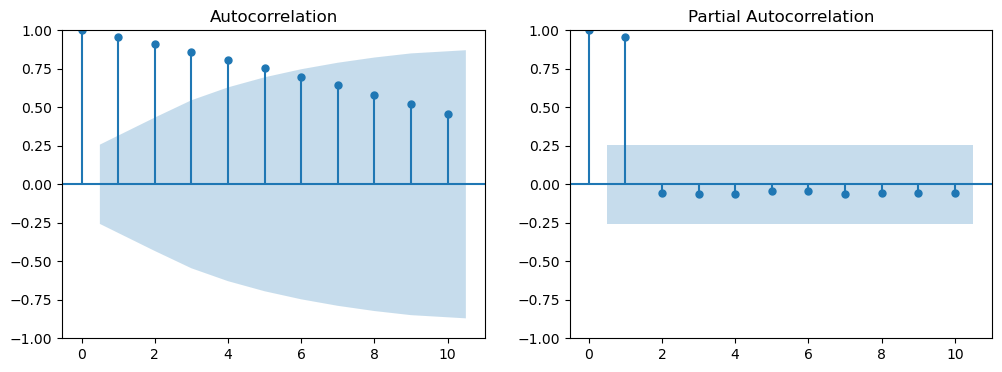

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(japan['value'], lags=10, ax=ax[0])
plot_pacf(japan['value'], lags=10, ax=ax[1])
plt.show()

## b)

Заметен возрастающий тренд, при этом начиная с ~1993 года ряд стабилизируется.\
Процесс не похож на стационарный, так как среднее меняется со временем.

### ADF тест

H0: ряд нестационарен\
H1: ряд стационарен

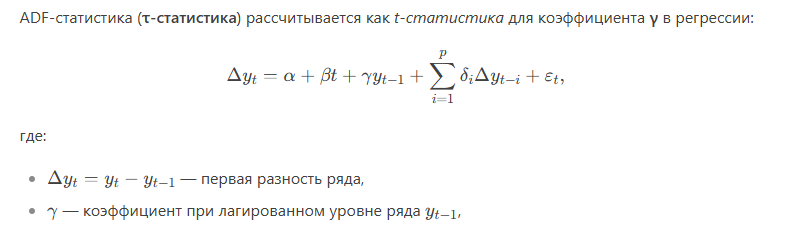

In [53]:
from statsmodels.tsa.stattools import adfuller


adf_test = adfuller(japan['value'], regression="ct") 

In [54]:
adf_test[1]

0.9387052809097217

p-value > 0.05 => **ряд нестационарен**

Я выбрал спецификацию ADF теста с трендом и константой ('ct') потому, что **на графике явно заметен возрастающий тренд**, и постоянного среднего точно нет(в этом случае лучше применять просто 'c').

## c)

In [58]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

In [59]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [60]:
ts_japan = japan.set_index('observation_date')['value'] # Делаем индексом дату, берем значение

In [61]:
ETS_japan = ExponentialSmoothing(
    ts_japan,
    trend="add",       
    seasonal=None,     # предполагаю что сезонности нет
    damped_trend=True # так как тренд замедляется
).fit()

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



In [62]:
ETS_japan.summary()

Dep. Variable:,value,No. Observations:,58
Model:,ExponentialSmoothing,SSE,110.755
Optimized:,True,AIC,47.519
Trend:,Additive,BIC,57.821
Seasonal:,None,AICC,49.759
Seasonal Periods:,None,Date:,"Sun, 31 Aug 2025"
Box-Cox:,False,Time:,00:47:41
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
smoothing_trend,0.8459776,beta,True


In [63]:
ETS_japan.params

{'smoothing_level': 0.9999999850988388,
 'smoothing_trend': 0.8459775987008183,
 'smoothing_seasonal': nan,
 'damping_trend': 0.8635690411207568,
 'initial_level': 17.251973057007582,
 'initial_trend': 2.239714696948053,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [64]:
# нахожу отстатки модели
y_true = ts_japan.values
y_pred = ETS_japan.fittedvalues
residuals = y_true - y_pred
residuals = residuals[~np.isnan(residuals)]

In [65]:
sigma2 = round(ETS_japan.sse / len(residuals), 2)
sigma = np.sqrt(sigma2)

**Уровень**: l_t = alpha * y_t + (1-alpha) * (l_{t-1} + phi * b_{t-1})\
**Тренд**: b_t = beta * (l_t - l_{t-1}) + (1-beta) * phi * b_{t-1}

## d)

**на 1 шаг**\
ŷ_{t+1} = l_t + phi * b_t\
ДИ: ŷ_{t+1} ± z * sigma * sqrt(1 + alpha²)\
где z = 1.28 (для 80% ДИ)

**на 2 шага**\
ŷ_{t+2} = l_t + phi * b_t + phi² * b_t\
ДИ: ŷ_{t+2} ± z * sigma * sqrt(1 + alpha² + alpha²*(1+beta*phi)²)\
где z = 1.28

In [70]:
alpha = ETS_japan.params['smoothing_level']
beta = ETS_japan.params['smoothing_trend'] 
phi = ETS_japan.params['damping_trend']
sigma = np.sqrt(ETS_japan.sse / len(ts_japan))

#Последние значения
l_t = ETS_japan.level[-1]  #последний уровень
b_t = ETS_japan.trend[-1]  #последний тренд

#Прогноз на 1 шаг
y_hat_1 = l_t + phi * b_t
#80% ДИ для 1 шага
z = 1.28
se_1 = sigma * np.sqrt(1 + alpha**2)
ci_lower_1 = y_hat_1 - z * se_1
ci_upper_1 = y_hat_1 + z * se_1

#Прогноз на 2 шага
y_hat_2 = l_t + phi * b_t + phi**2 * b_t
#80% ДИ для 2 шагов
se_2 = sigma * np.sqrt(1 + alpha**2 + alpha**2 * (1 + beta*phi)**2)
ci_lower_2 = y_hat_2 - z * se_2
ci_upper_2 = y_hat_2 + z * se_2

C:\Users\User\AppData\Local\Temp\ipykernel_20960\737762934.py:7: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\User\AppData\Local\Temp\ipykernel_20960\737762934.py:8: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [71]:
print(f'Прогноз на 1 шаг вперед "руками": {y_hat_1:.2f}   80% ДИ для прогноза: ({ci_lower_1:.2f}, {ci_upper_1:.2f})')
print(f'Прогноз на 2 шага вперед "руками": {y_hat_2:.2f}   80% ДИ для прогноза: ({ci_lower_2:.2f}, {ci_upper_2:.2f})')

Прогноз на 1 шаг вперед "руками": 105.71   80% ДИ для прогноза: (103.21, 108.21)
Прогноз на 2 шага вперед "руками": 106.46   80% ДИ для прогноза: (102.51, 110.41)


## e)

In [73]:
help(ETS_japan.predict)

Help on method predict in module statsmodels.tsa.holtwinters.results:

predict(start=None, end=None) method of statsmodels.tsa.holtwinters.results.HoltWintersResultsWrapper instance
    predict(self, start=None, end=None)

    In-sample prediction and out-of-sample forecasting

    Parameters
    ----------
    start : int, str, or datetime, optional
        Zero-indexed observation number at which to start forecasting, ie.,
        the first forecast is start. Can also be a date string to
        parse or a datetime type. Default is the the zeroth observation.
    end : int, str, or datetime, optional
        Zero-indexed observation number at which to end forecasting, ie.,
        the first forecast is start. Can also be a date string to
        parse or a datetime type. However, if the dates index does not
        have a fixed frequency, end must be an integer index if you
        want out of sample prediction. Default is the last observation in
        the sample.

    Returns
    

In [75]:
forecast_1step, conf_int_1step = ETS_japan.predict(
    start=len(ts_japan), 
    end=len(ts_japan),  #для 1 шага
  #  return_conf_int=True,
    alpha=0.2  #для 80% ДИ
)

print(f'Прогноз на 1 шаг вперед встроенной функцией: {forecast_1step.iloc[0]:.2f}   80% ДИ для прогноза: {(conf_int_1step[0])}')

TypeError: HoltWintersResults.predict() got an unexpected keyword argument 'alpha'

In [77]:
forecast_1step = ETS_japan.forecast(steps=1)
ci = forecast_1step.summary_frame(alpha=0.2)  # 80% ДИ

print(ci[['mean', 'mean_ci_lower', 'mean_ci_upper']])

AttributeError: 'Series' object has no attribute 'summary_frame'

In [79]:
print(statsmodels.__version__)

0.14.4


**В последних версиях statsmodels нет атрибута get_prediction(), поэтому невозможно в явном виде получить ДИ**

## f)

### Проверяю стационарность

In [84]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts_japan, regression='ct')
print(f'{result[0]:.3f}, p-value: {result[1]:.3f}')

-1.038, p-value: 0.939


Выражен возрастающий тренд, ряд нестационарный. Поэтому применяю дифференцирование:

In [87]:
ts_japan_diff = ts_japan.diff().dropna()

### ACF + PACF

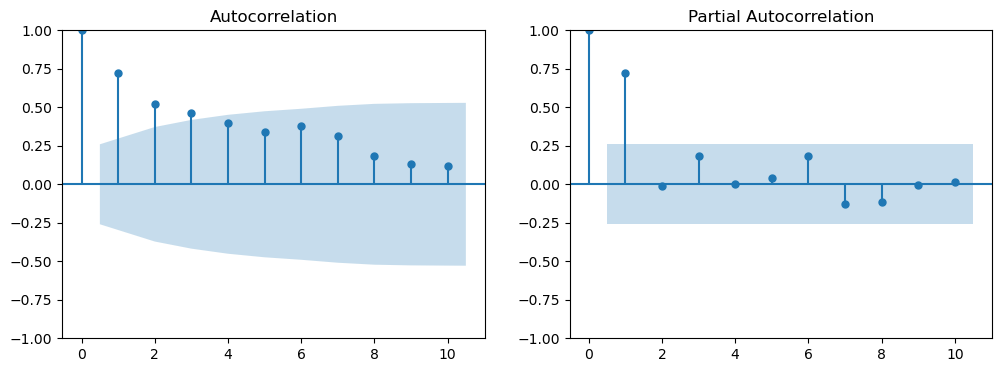

In [90]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts_japan_diff, lags=10, ax=ax[0])
plot_pacf(ts_japan_diff, lags=10, ax=ax[1])
plt.show()

PACF резко обрывается после первого лага => это **AR процесс**. ACF плавно затухает

### Перебор потенциально подходящих параметров p, d, q в ARIMA

In [94]:
from statsmodels.tsa.arima.model import ARIMA

In [96]:
model_arima1 = ARIMA(ts_japan_diff, order=(1,0,0)).fit() #d=0, так как дифференцировал ряд
print(model_arima1.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   57
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -98.803
Date:                Sun, 31 Aug 2025   AIC                            203.606
Time:                        00:47:59   BIC                            209.735
Sample:                    01-01-1961   HQIC                           205.988
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4971      0.832      1.799      0.072      -0.134       3.128
ar.L1          0.7133      0.064     11.091      0.000       0.587       0.839
sigma2         1.8523      0.254      7.285      0.0

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



In [98]:
model_arima2 = ARIMA(ts_japan_diff, order=(1,0,1)).fit() # d=0, так как дифференцировал ряд
print(model_arima2.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   57
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -98.799
Date:                Sun, 31 Aug 2025   AIC                            205.598
Time:                        00:47:59   BIC                            213.770
Sample:                    01-01-1961   HQIC                           208.774
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4989      0.827      1.813      0.070      -0.122       3.119
ar.L1          0.7022      0.100      7.007      0.000       0.506       0.899
ma.L1          0.0232      0.122      0.190      0.8

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



**У первой модели значения AIC, BIC меньше => используем ее**

### Диагностика модели

In [102]:
residuals1 = model_arima1.resid

# Тест на автокорреляцию 
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals1, lags=10)
print(lb_test)

# Тест на нормальность 
from scipy.stats import shapiro
shapiro_test = shapiro(residuals1)
print(f"Shapiro p-value: {shapiro_test[1]:.3f}")

     lb_stat  lb_pvalue
1   0.018367   0.892197
2   1.011276   0.603121
3   1.534460   0.674340
4   1.750667   0.781495
5   2.223596   0.817420
6   5.289687   0.507231
7   6.882427   0.441223
8   7.319702   0.502565
9   7.430307   0.592412
10  8.232912   0.606098
Shapiro p-value: 0.001


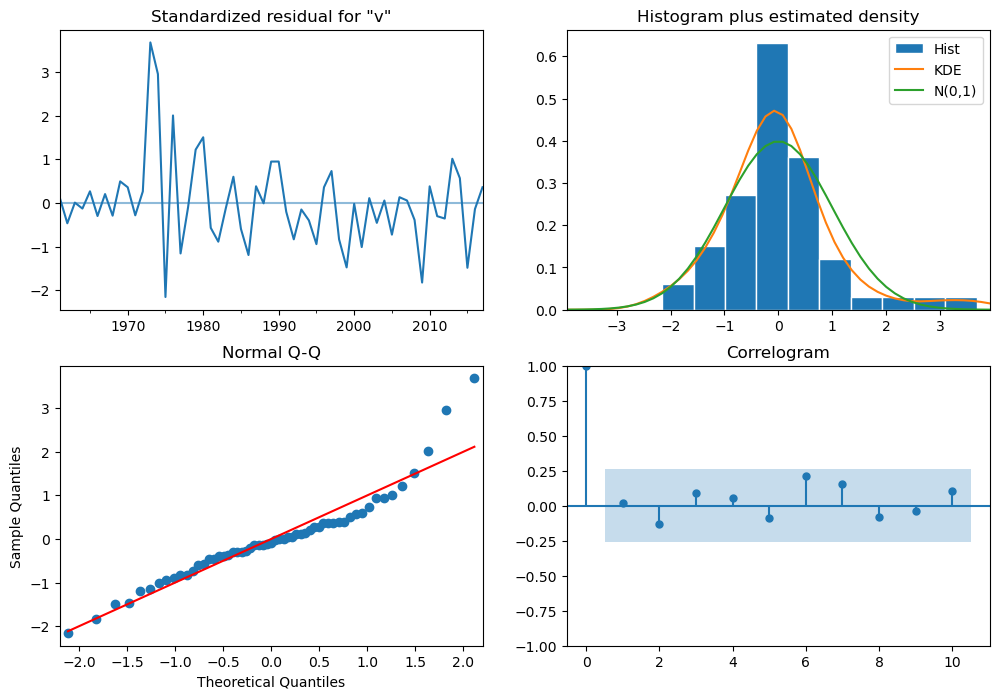

In [104]:
model_arima1.plot_diagnostics(figsize=(12, 8))
plt.show()

**Распределение остатков отличается от нормального (p-value теста Шапиро-Уилка < 0.05). При этом автокорреляции в остатках нет (p-value в тесте Льюнга-Бокса > 0.05)**\
Модель адекватно оценила временную структуру данных, её **можно использовать для прогнозов**

## g)

In [108]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [109]:
from pmdarima import auto_arima

In [110]:
model_auto_arima = auto_arima(
    ts_japan,           
    seasonal=False,      
    stepwise=True,       
    trace=True,          
    suppress_warnings=True,  
    error_action="ignore",   
    information_criterion='aic'  #Критерий оптимизации (AIC)
)

print(model_auto_arima.summary())

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=206.671, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=207.716, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=206.461, Time=0.01 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=204.674, Time=0.01 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.07 sec

Best model:  ARIMA(0,2,0)(0,0,0)[0]          
Total fit time: 0.230 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   58
Model:               SARIMAX(0, 2, 0)   Log Likelihood                -101.337
Date:                Sun, 31 Aug 2025   AIC                            204.674
Time:                        00:48:04   BIC                            206.699
Sample:                    01-01-1960   HQIC                           205.459
                        

### Сравнение подобранной мной и автоматически подобранной модели

Модели нужно обучать на одних и тех же данных, поэтому я **переобучу первую модель на исходный ряд** (сначала обучил на дифференцированном). Поэтому **сейчас я использую (1,1,0)**

In [116]:
model_arima1_new = ARIMA(ts_japan, order=(1,1,0)).fit() #d=0, так как дифференцировал ряд
print(model_arima1_new.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   58
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -100.766
Date:                Sun, 31 Aug 2025   AIC                            205.533
Time:                        00:48:05   BIC                            209.619
Sample:                    01-01-1960   HQIC                           207.121
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8160      0.043     19.189      0.000       0.733       0.899
sigma2         1.9710      0.246      8.015      0.000       1.489       2.453
Ljung-Box (L1) (Q):                   0.33   Jarque-

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



**Модель с (0,2,0) лучше по критериям AIC, BIC**\
Это говорит о том, что **ряд сильно нестационарный (нужно двойное дифференцироавние)**

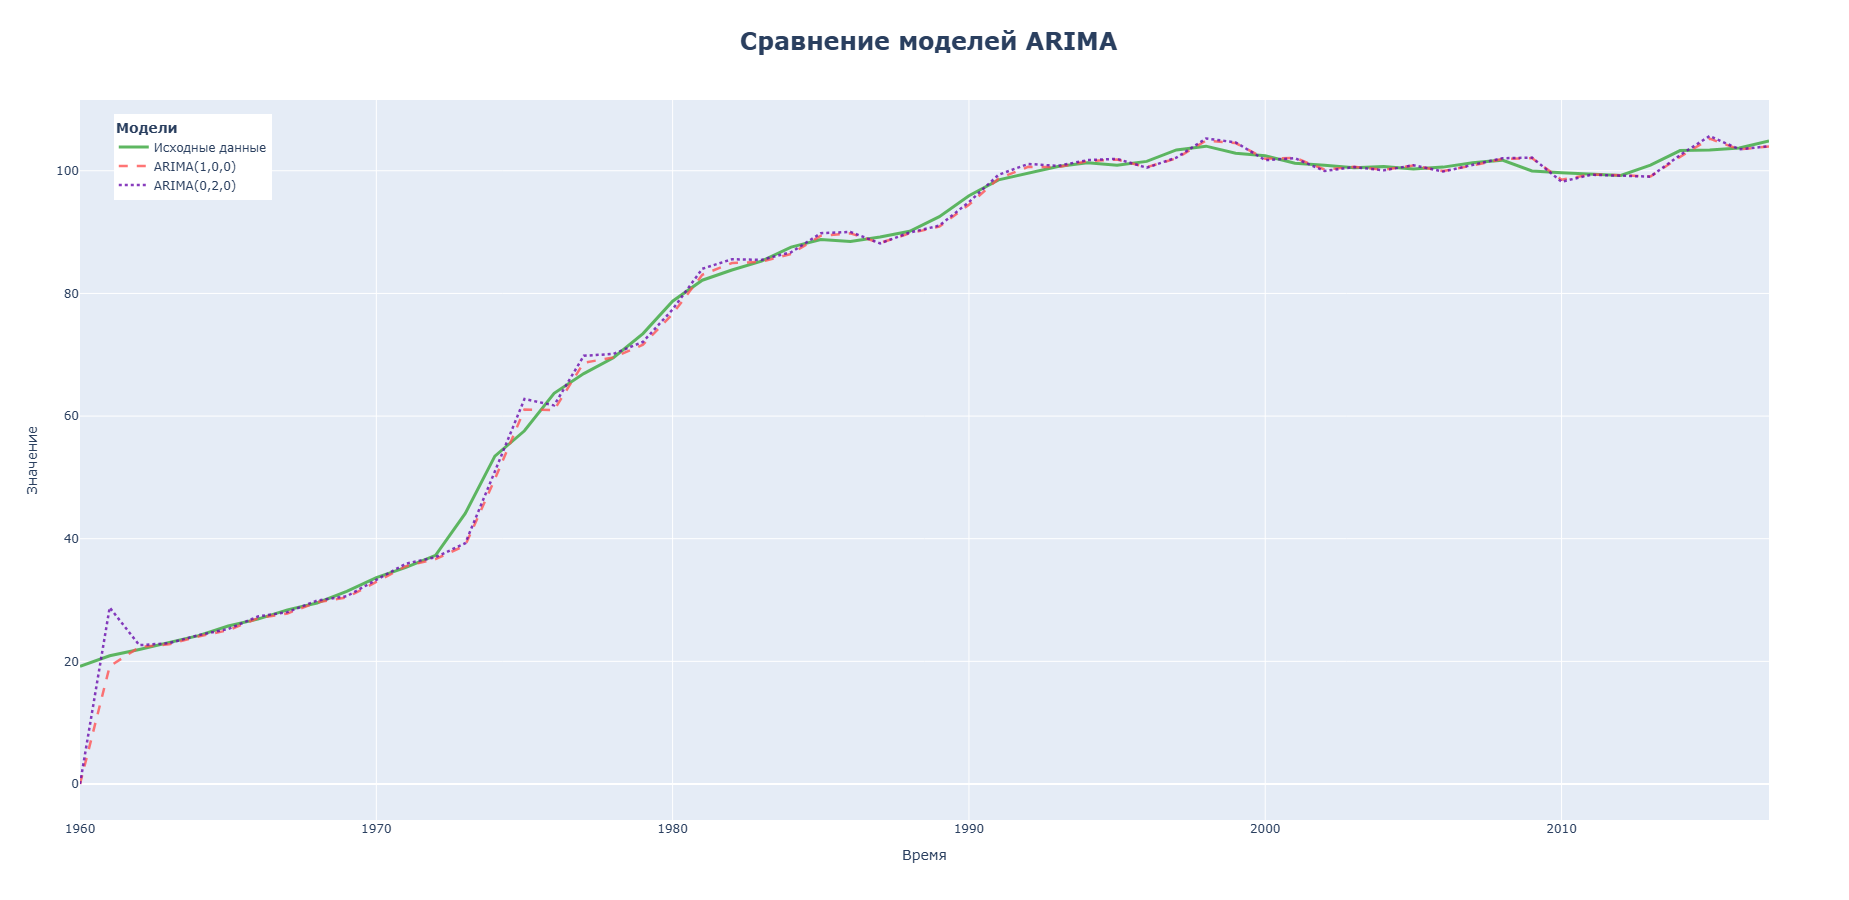

In [135]:
import plotly.graph_objects as go
# в создании этого графика мне помог deepseek
df_plot = pd.DataFrame({
    'Исходные_данные': ts_japan,
    'ARIMA100': model_arima1_new.fittedvalues if hasattr(model_arima1_new, 'fittedvalues') else model_arima1_new.predict(start=0, end=len(ts_japan)-1),
    'ARIMA020': model_auto_arima.fittedvalues() if hasattr(model_auto_arima, 'fittedvalues') else model_auto_arima.predict_in_sample()
})

df_plot = df_plot.reset_index()
df_plot = df_plot.rename(columns={'observation_date': 'date'})

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_plot['date'], 
    y=df_plot['Исходные_данные'],
    name='Исходные данные',
    line=dict(color='#4CAF50', width=3),
    opacity=0.9
))

fig.add_trace(go.Scatter(
    x=df_plot['date'], 
    y=df_plot['ARIMA100'],
    name='ARIMA(1,0,0)',
    line=dict(color='#FF5252', width=2.5, dash='dash'),
    opacity=0.8
))

fig.add_trace(go.Scatter(
    x=df_plot['date'], 
    y=df_plot['ARIMA020'],
    name='ARIMA(0,2,0)',
    line=dict(color='#6A0DAD', width=2.5, dash='dot'),
    opacity=0.8
))


fig.update_layout(
    title=dict(
        text='<b> Сравнение моделей ARIMA</b>',
        font=dict(size=24),
        x=0.5
    ),
    xaxis=dict(title='Время'),
    yaxis=dict(title='Значение'),
    legend=dict(
        title=dict(text='<b>Модели</b>'),
        x=0.02,
        y=0.98
    ),
    hovermode='x unified',
    width=1600,
    height=900
)
import plotly.io as pio
fig.write_html("arimas_plot.html")
fig.show()

Как можно заметить, **обе модели хорошо справляются с предсказанием ряда**. На многих участках их предсакзания почти идентичны

**Графики не отображаются в github. поэтому поместил отдельно в этот же репозиторий график arimas_plot.png**

## h)

Добавим сюда ETS модель из пункта (с):

In [140]:
fitted_ets = ETS_japan.fittedvalues

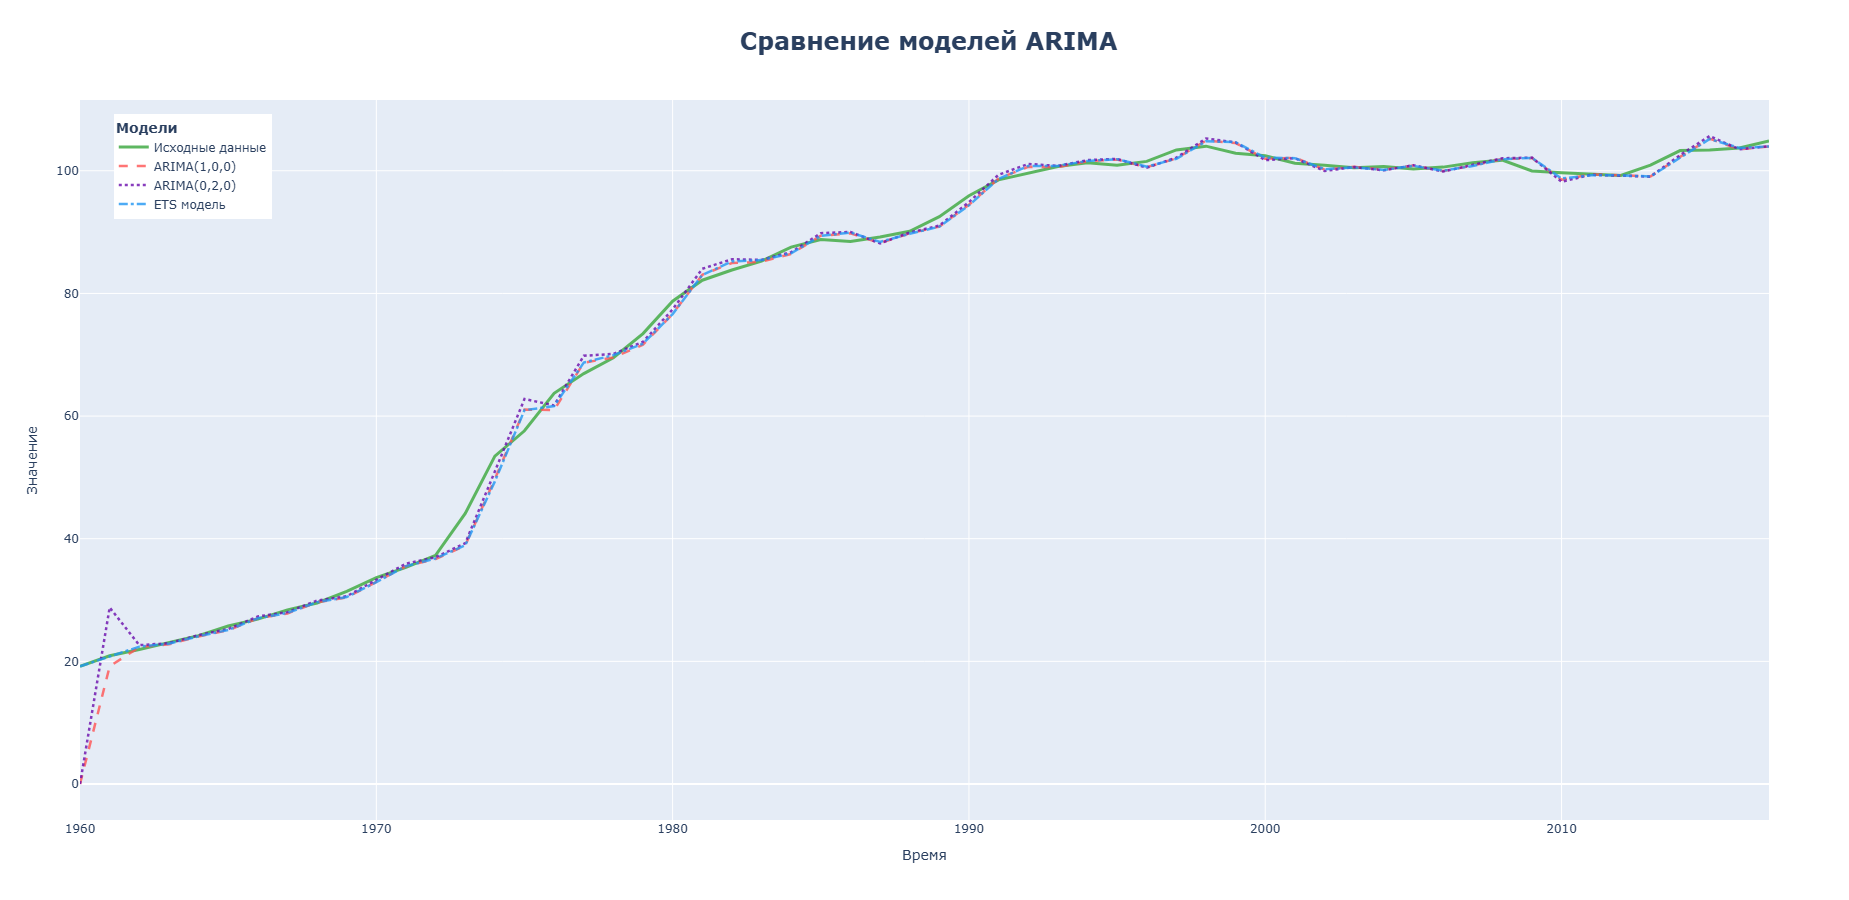

In [142]:
df_plot = pd.DataFrame({
    'Исходные_данные': ts_japan,
    'ARIMA100': model_arima1_new.fittedvalues if hasattr(model_arima1_new, 'fittedvalues') else model_arima1_new.predict(start=0, end=len(ts_japan)-1),
    'ARIMA020': model_auto_arima.fittedvalues() if hasattr(model_auto_arima, 'fittedvalues') else model_auto_arima.predict_in_sample()
})
df_plot['ETS'] = fitted_ets
df_plot = df_plot.reset_index()
df_plot = df_plot.rename(columns={'observation_date': 'date'})

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_plot['date'], 
    y=df_plot['Исходные_данные'],
    name='Исходные данные',
    line=dict(color='#4CAF50', width=3),
    opacity=0.9
))

fig.add_trace(go.Scatter(
    x=df_plot['date'], 
    y=df_plot['ARIMA100'],
    name='ARIMA(1,0,0)',
    line=dict(color='#FF5252', width=2.5, dash='dash'),
    opacity=0.8
))

fig.add_trace(go.Scatter(
    x=df_plot['date'], 
    y=df_plot['ARIMA020'],
    name='ARIMA(0,2,0)',
    line=dict(color='#6A0DAD', width=2.5, dash='dot'),
    opacity=0.8
))

fig.add_trace(go.Scatter(
    x=df_plot['date'], 
    y=df_plot['ETS'],
    name='ETS модель',
    line=dict(color='#2196F3', width=2.5, dash='dashdot'),  # яркий синий
    opacity=0.8
))

fig.update_layout(
    title=dict(
        text='<b> Сравнение моделей ARIMA</b>',
        font=dict(size=24),
        x=0.5
    ),
    xaxis=dict(title='Время'),
    yaxis=dict(title='Значение'),
    legend=dict(
        title=dict(text='<b>Модели</b>'),
        x=0.02,
        y=0.98
    ),
    hovermode='x unified',
    width=1600,
    height=900
)
fig.write_html("arimas_ets_plot.html")
fig.show()

**Графики не отображаются в github. поэтому поместил отдельно в этот же репозиторий график arimas_ets_plot.png**

### Сравнение качества моделей на трейн выборке

Мне стало интересно **сравнить модели по метрикам качества** для временных рядов. Так как у нас есть только трейн выборка, и не было задания с разделением ряда, посмотрим, как модели справляются на трейн выборке

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np


y_true = ts_japan

#ARIMA(1,0,0)
y_pred_arima100 = model_arima1_new.fittedvalues

#AutoARIMA(0,2,0)
y_pred_arima020 = model_auto_arima.fittedvalues()

#ETS
y_pred_ets = ETS_japan.fittedvalues

In [ ]:
def calculate_metrics(y_true, y_pred, model_name):
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    return {
        'Модель': model_name,
        'MAE': mae,
        'MSE': mse, 
        'RMSE': rmse,
        'MAPE': mape,
    }

metrics_arima100 = calculate_metrics(y_true, y_pred_arima100, 'ARIMA(1,0,0)')
metrics_arima020 = calculate_metrics(y_true, y_pred_arima020, 'ARIMA(0,2,0)')
metrics_ets = calculate_metrics(y_true, y_pred_ets, 'ETS')


import pandas as pd
metrics_df = pd.DataFrame([metrics_arima100, metrics_arima020, metrics_ets])
metrics_df = metrics_df.set_index('Модель')
print("Метрики качества моделей:")
display(metrics_df.style
        .background_gradient(subset=['MAE', 'MSE', 'RMSE', 'MAPE'], cmap='RdYlGn_r'))

По всем критериям лучшей стала **ETS модель**.\
При этом я бы не ориентировался только на этот результат, а попробовал **поделить ряд на трейн и тест и сравнить метрики на тестовой выборке**

# №4

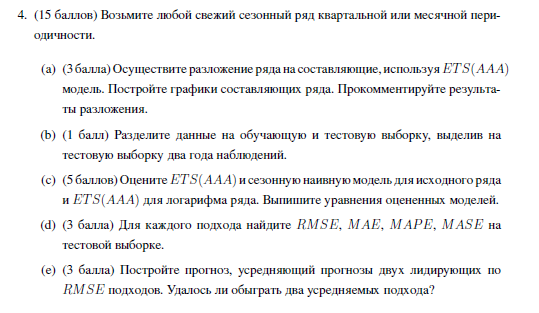

Я нашел ряд, отображающий **продажи в алкомаркетах Великобритании с 1992 по март 2025 года**

In [ ]:
import random

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

In [ ]:
retail = pd.read_csv('df11.csv')

In [ ]:
retail.tail()

In [ ]:
retail['observation_date'] = pd.to_datetime(retail['observation_date'])

retail = retail.rename(columns={'MRTSSM4453USN': 'value'})
retail['id'] = 1

In [ ]:
fig = go.Figure()
seed_everything()
random_ids = np.random.choice(retail["id"].unique(), 1, replace=False)   

for i in random_ids:
    fig.add_trace(
        go.Scatter(x=retail[retail["id"] == i]["observation_date"], y=retail[retail["id"] == i]["value"], name=str(i))
    )
fig.update_layout(title="Data on Retail Sales: Beer, Wine, and Liquor Stores", xaxis_title="Date", yaxis_title="Value")
fig.show()

**Это данные по продажам, поэтому логично что заметны пики в декабре, спады в январе**

## a)

In [ ]:
sales = retail['value']

In [ ]:
model_retail = ExponentialSmoothing(
    sales,
    trend="add",        
    seasonal="add",     
    seasonal_periods=12 
)
model_retail_fit = model_retail.fit()

### Разложение ряда на компоненты

In [ ]:
retail_comp = pd.DataFrame({
    'Ряд': sales,
    'Тренд': model_retail_fit.trend,
    'Сезонность': model_retail_fit.season,
    'Остатки': model_retail_fit.resid
})

In [ ]:
retail_comp

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8))
retail_comp['Ряд'].plot(ax=axes[0], title='Ряд')
retail_comp['Тренд'].plot(ax=axes[1], title='Тренд')
retail_comp['Сезонность'].plot(ax=axes[2], title='Сезонность')
retail_comp['Остатки'].plot(ax=axes[3], title='Остатки')
plt.tight_layout()
plt.show()

**Интересен график тренда**. Заметен резкий рост в районе 330го месяца, а потом заметный спад. До 330й недели ряд тоже демонстрирует возрастающий тренд, но он достаточно плавный, на контрасте с почти **вертикальным ростом,** о котором написал до этого.

**Сезонность неоднородна**: амплитуда колебаний, то есть дисперсия ряда увеличивается со временем, поэтому скорее всего **модель с мультипликативной сезонностью подошла бы лучше.** Заметны **классические для данных по продажам пики в декабре**.

Дисперсия остатков растет со временем, что указывает на **возможную гетероскедастичность**

## b)

In [ ]:
test_retail = retail[retail['observation_date']>='2023-03-01']
train_retail = retail[retail['observation_date']<'2023-03-01']

## с)

In [ ]:
sales_train = train_retail['value']
sales_test = test_retail['value']

### ETS

In [ ]:
model_retail_с = ExponentialSmoothing(
    sales_train,
    trend="add",        
    seasonal="add",     
    seasonal_periods=12 
)
model_retail_с_fit = model_retail_с.fit()

### Seasonal Naive

In [ ]:
seasonal_naive_retail_c = sales.shift(12)  

### ETS для логарифмированного ряда

In [ ]:
sales_train_log = np.log(sales_train)
sales_test_log = np.log(sales_test)

In [ ]:
model_retail_с_log = ExponentialSmoothing(
    sales_train_log,
    trend="add",        
    seasonal="add",     
    seasonal_periods=12 
)
model_retail_с_log_fit = model_retail_с_log.fit()

## d)

In [ ]:
len(sales_test)

### Получаю прогнозы

In [ ]:
forecast_ets = model_retail_с_fit.forecast(steps=len(sales_test))

forecast_sn = seasonal_naive_retail_c[-25:]

forecast_ets_log = model_retail_с_log_fit.forecast(steps=len(sales_test))

### Считаю метрики

In [ ]:
forecast_ets_log_exp = np.exp(forecast_ets_log)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,  mean_absolute_percentage_error

In [ ]:
def calculate_mase(train, test, forecast, seasonal_period=1):
    naive_forecast = train[:-seasonal_period]
    mae_naive = mean_absolute_error(train[seasonal_period:], naive_forecast)
    mae_model = mean_absolute_error(test, forecast)
    return mae_model / mae_naive

In [ ]:
# здесь нашел функцию https://www.geeksforgeeks.org/python/how-to-calculate-mape-in-python/
def calculate_mape(actual, predicted) -> float:

    # Convert actual and predicted
    # to numpy array data type if not already
    if not all([isinstance(actual, np.ndarray),
                isinstance(predicted, np.ndarray)]):
        actual = np.array(actual) 
        predicted = np.array(predicted)

    # Calculate the MAPE value and return
    return round(np.mean(np.abs((
      actual - predicted) / actual)) * 100, 2)

In [ ]:
sales_test = sales_test.astype(float)

In [ ]:
metrics = []
seasonal_period=1
metrics.append({
        'Model': 'Seasonal Naive',
        'MAE': mean_absolute_error(sales_test, forecast_sn),
        'MASE': calculate_mase(sales_train, sales_test, forecast_sn, seasonal_period),
        'RMSE': np.sqrt(mean_squared_error(sales_test, forecast_sn)),
        'MAPE': calculate_mape(sales_test, forecast_sn)
    
    })

metrics.append({
        'Model': 'ETS (AAA)',
        'MAE': mean_absolute_error(sales_test, forecast_ets),
        'MASE': calculate_mase(sales_train, sales_test, forecast_ets, seasonal_period),
        'RMSE': np.sqrt(mean_squared_error(sales_test, forecast_ets)),
        'MAPE': calculate_mape(sales_test, forecast_ets)
    })

metrics.append({
        'Model': 'ETS (AAA) for log',
        'MAE': mean_absolute_error(sales_test, forecast_ets_log_exp),
        'MASE': calculate_mase(sales_train, sales_test, forecast_ets_log_exp, seasonal_period),
        'RMSE': np.sqrt(mean_squared_error(sales_test, forecast_ets_log_exp)),
        'MAPE': calculate_mape(sales_test, forecast_ets_log_exp)
    })

metrics1 = pd.DataFrame(metrics).round(3)

In [ ]:
display(metrics1.style
        .background_gradient(subset=['MAE', 'MASE', 'RMSE', 'MAPE'], cmap='RdYlGn_r'))

Заметим, что **сезонный наивный прогноз оказался лучшим по всем критериям, еще и с заметным отрывом**\
Это **классическая ситуация для рядов продаж**, так как в них обычно присутствует очень сильная сезонность, и многие значения почти повторяются спустя период

При этом ETS для логарифмированного ряда заметно лучше, чем обычный ETS, что подтверждает **состоятельность подхода логарифмирования**

## e)

### Прогноз, усредняющий 2 лидирующих

In [ ]:
forecast_lead_mean = (forecast_sn + forecast_ets_log_exp) / 2

In [ ]:
metrics.append({
        'Model': 'Mean of Seasonal Naive and ETS (AAA) for log forecasts',
        'MAE': mean_absolute_error(sales_test, forecast_lead_mean),
        'MASE': calculate_mase(sales_train, sales_test, forecast_lead_mean, seasonal_period),
        'RMSE': np.sqrt(mean_squared_error(sales_test, forecast_lead_mean)),
        'MAPE': calculate_mape(sales_test, forecast_lead_mean)
    })

In [ ]:
metrics2 = pd.DataFrame(metrics)

In [ ]:
display(metrics2.style
        .background_gradient(subset=['MAE', 'MASE', 'RMSE', 'MAPE'], cmap='RdYlGn_r'))

Да, **удалось получить самый точный прогноз**, причем качество улучшлось почти в 1.5 раза по MAPE относительно сезонного наивного прогноза, который был лучшим до этого

<h1 style="font-size: 3em; font-weight: bold; color: #2E86AB; text-align: center;">
    Панельные данные
</h1>

# №5

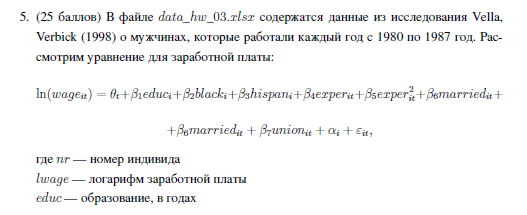

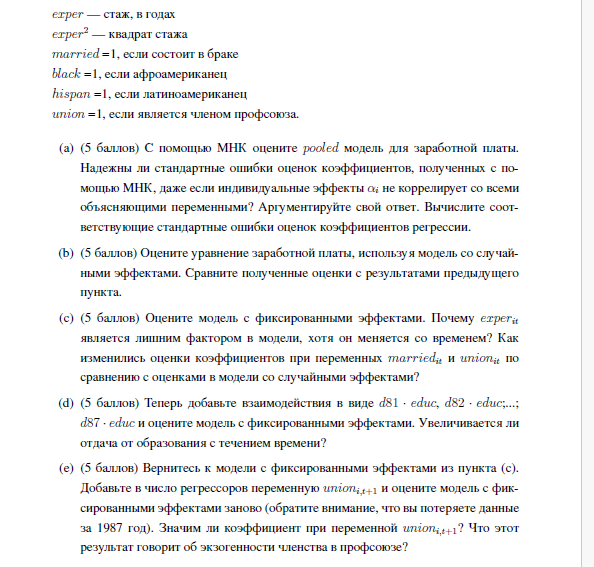

In [ ]:
df = pd.read_excel('data_hw_03.xlsx')

In [ ]:
df.head()

In [ ]:
df.shape

nr — номер индивида\
lwage — логарифм заработной платы\
educ — образование, в годах\
exper — стаж, в годах\
exper2 — квадрат стажа\
married =1, если состоит в браке\
black =1, если афроамериканец\
hispan =1, если латиноамериканец\
union =1, если является членом профсоюза

In [ ]:
df['hisp'].value_counts()

In [ ]:
df['exper2'] = df['exper']**2

In [ ]:
df1 = df.copy(deep=True)

df1 = df1.set_index(['nr', 'year'])

In [ ]:
df1.columns

## a)

In [ ]:
import statsmodels.api as sm

In [ ]:
X = df1[['educ', 'exper', 'exper2', 'married', 'black', 'hisp', 'union']]
X = sm.add_constant(X) 
y = df1['lwage']

pooled_ols = sm.OLS(y, X).fit()
print(pooled_ols.summary())

Нет, **стандартные ошибки коэффициентов, полученные при помощи МНК в данном случае ненадежны**.
Это происходит потому, что:
1) **Pooled OLS не учитывает панельную структуру**, оценивает данные как обычные cross-section
2) Отсутствие корреляции между αi и Xi не отменяет факта, что **наблюдения для каждого конкретного индивида по времени зависимы.**
3) **Возможна гетероскедастичность**, так как дисперсия ошибок может различаться для разных индивидов

In [ ]:
std_err = pd.DataFrame()
std_err['Regressor'] = X.columns
std_err['std err'] = pooled_ols.bse.values

In [ ]:
std_err

## б)

In [ ]:
from linearmodels import RandomEffects

In [ ]:
re_model_formula = 'lwage ~ 1 + educ + exper + exper2 +  married + black + hisp + union' 

In [ ]:
re_model = RandomEffects.from_formula(re_model_formula, data=df1).fit()
print(re_model.summary)

In [ ]:
std_err['std err RE model'] = re_model.std_errors.values

In [ ]:
std_err['difference(%)'] = ((std_err['std err RE model'] - std_err['std err'])/std_err['std err'])*100

In [ ]:
std_err

In [ ]:
coefs = pd.DataFrame()
coefs['Regressor'] = X.columns
coefs['coef Pooled OLS'] = pooled_ols.params.values
coefs['coef RE model'] = re_model.params.values
coefs['difference(%)'] = ((coefs['coef RE model'] - coefs['coef Pooled OLS'])/coefs['coef Pooled OLS'])*100

In [ ]:
coefs.round(3)

Оценки моделей отличаются, но **для большинства регрессоров различия не критичны**

**После оценки 3ей модели мы сравним все 3 модели**

## c)

In [ ]:
from linearmodels import PanelOLS

In [ ]:
fe_model_formula = 'lwage ~ 1 + educ + exper + exper2 +  married + black + hisp + union + EntityEffects' 

In [ ]:
fe_model = PanelOLS.from_formula(
    fe_model_formula,  # EntityEffects - фиксированные эффекты 
    data=df1,
    drop_absorbed=True).fit()

In [ ]:
fe_model.summary

In [ ]:
# Проверка связи опыта и года
print(df[['exper', 'year']].corr())

**exper не удалился сам, при этом корреляция с годом очень высокая**. Поэтому я решил сам удалить exper и оценить результаты

**Exper является лишним фактором потому, что напрямую зависит от года. То есть + 1 год => +1 год опыта у работающего человека**

In [ ]:
fe_model_formula_upd = 'lwage ~ 1 + exper2 +  married + union + EntityEffects' 

In [ ]:
fe_model_upd = PanelOLS.from_formula(
    fe_model_formula_upd,  # EntityEffects - фиксированные эффекты 
    data=df1).fit()

In [ ]:
fe_model_upd.summary

In [ ]:
fe_re = pd.DataFrame()
fe_re['Regressor'] = ['Intercept', 'exper2', 'married', 'union']
coefs_re = [-0.135843, -0.0038, 0.0645, 0.1061]
fe_re['coef RE model'] = coefs_re
fe_re['coef FE model'] = fe_model_upd.params.values
fe_re['difference(%)'] = (((fe_re['coef FE model'] - fe_re['coef RE model'])/fe_re['coef RE model'])*100).round(3)

In [ ]:
fe_re

**Оценки коэффициентов сильно различаются в RE и FE моделях**. Для переменной married эффект увеличился на 62%, что указывает на наличие положительной корреляции между брачным статусом и неучтенными индивидуальными эффектами людей.\
Для union снижение на 23%, свидетельствующее о том, что часть эффекта членства в профсоюзе в RE модели объяснялась постоянными характеристиками работников.

### Сравнение трёх моделей

#### Pooled vs RE: тест Бройша-Пагана на равенство нулю дисперсии индивидуальных эффектов

In [ ]:
from scipy import stats as st

In [ ]:
# в этом задании мне помог deepseek

pooled_resid = pooled_ols.resid

df_resid = pd.DataFrame({
    'nr': df1.index.get_level_values('nr'),  
    'residuals': pooled_resid
})
df_resid = df_resid.rename(columns={'nr': 'nrr'})

df_resid_group_means = df_resid.groupby('nrr').mean()

ssr_grouped_means = (df_resid_group_means['residuals']**2).sum()
ssr_pooled = np.sum(pooled_resid**2)  # сумма квадратов остатков


n = len(df_resid_group_means)  # количество индивидов
T = len(df1) / n  # среднее количество наблюдений на индивида

print(f"Количество индивидов (n): {n}")
print(f"Среднее наблюдений на индивида (T): {T:.2f}")

# Вычисляем LM статистику
LM_statistic = (n * T) / (2 * (T - 1)) * (((T * T * ssr_grouped_means) / ssr_pooled - 1))**2

print('LM Statistic = ' + str(LM_statistic))

# Критическое значение и p-value
alpha = 0.05
chi2_critical_value = st.chi2.ppf(q=(1.0 - alpha), df=1)
p_value = 1 - st.chi2.cdf(LM_statistic, df=1)
print('Критическое значение = ' + str(chi2_critical_value))

if LM_statistic > chi2_critical_value:
    print("Отклоняем H0: Есть значимые индивидуальные эффекты")
    print("Random Effects предпочтительнее Pooled OLS")
else:
    print("НЕ Отклоняем H0: Нет индивидуальных эффектов")
    print("Pooled OLS адекватна")

Тестовая статистика намного больше криитической. Значит, **индивидуальные эффекты есть и они очень значительные**

#### FE vs RE: анализ коэффициентов

In [ ]:
fe_re

Заметим, что у всех коэффициентов разница > 20%. Значит, **лучше выбрать FE модель**

## d)

In [ ]:
df1['d81_educ'] = df1['d81'] * df1['educ']
df1['d82_educ'] = df1['d82'] * df1['educ']
df1['d83_educ'] = df1['d83'] * df1['educ']
df1['d84_educ'] = df1['d84'] * df1['educ']
df1['d85_educ'] = df1['d85'] * df1['educ']
df1['d86_educ'] = df1['d86'] * df1['educ']
df1['d87_educ'] = df1['d87'] * df1['educ']

In [ ]:
formula_d = 'lwage ~ 1 + exper2 +  married + union + + d81_educ + d82_educ + d83_educ + d84_educ + d85_educ + d86_educ  + d87_educ + EntityEffects' 
# + d82*educ + d83*educ + d84*educ + d85*educ + d86*educ  + d87*educ + d81*educ

In [ ]:
fe_model_d = PanelOLS.from_formula(
    formula_d,  # EntityEffects - фиксированные эффекты 
    data=df1,
    drop_absorbed=False,  # Не удалять автоматически
    check_rank=False ).fit()

In [ ]:
fe_model_d.summary

**С течением времени отдача от образования увеличивается**.\
Коэффициент взаимодействия год-образование **растет с каждым годом**

In [ ]:

# Создаем данные для графика
edu_data = []
for year in range(81, 88):
    coef_name = f'd{year}_educ'
    if coef_name in fe_model_d.params:
        edu_data.append({
            'Год': 1900 + year,
            'Отдача от образования': fe_model_d.params[coef_name],
            'SE': fe_model_d.std_errors[coef_name]
        })

edu_df = pd.DataFrame(edu_data)

plt.figure(figsize=(12, 6))
sns.lineplot(data=edu_df, x='Год', y='Отдача от образования', 
             marker='o', linewidth=2, markersize=8, color='#2E86AB')

# доверительные интервалы
plt.fill_between(edu_df['Год'], 
                 edu_df['Отдача от образования'] - 1.96*edu_df['SE'],
                 edu_df['Отдача от образования'] + 1.96*edu_df['SE'],
                 alpha=0.2, color='#2E86AB')

plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.title('Динамика отдачи от образования во времени', fontsize=16, pad=20)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Коэффициент отдачи от образования', fontsize=12)
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

## e)

In [ ]:
# модель из пункта с)
#fe_model_formula_upd = 'lwage ~ 1 + exper2 +  married + union + EntityEffects' 

#fe_model_upd = PanelOLS.from_formula(
 #   fe_model_formula_upd,  # EntityEffects - фиксированные эффекты 
  #  data=df1).fit()

In [ ]:
df1[['union']]

In [ ]:
df1['next_value'] = df1.groupby('nr')['union'].shift(-1)


In [ ]:
df1 = df1.rename(columns={'next_value': 'union_i_t1'})

In [ ]:
# убираю наблюдения за 1987 год
df1_e = df1[df1.index.get_level_values('year') != 1987]

In [ ]:
# новая модель

fe_model_formula_new = 'lwage ~ 1 + exper2 +  married + union + union_i_t1 + EntityEffects' 

fe_model_new = PanelOLS.from_formula(
    fe_model_formula_new, 
    data=df1).fit()
fe_model_new.summary

**Коэффициент перед union_i_t1 значим на 5% уровне значимости**.\
Это говорит о том, что **членство в профсоюзе в будущем влияет на текущую зарплату** => **предположение об экзогенности нарушается**